# Data Science Fresher Training – Medium-Level ML Project (Stroke Prediction)

This notebook is designed for **fresher / junior Data Scientists** based on a typical Job Description (JD).  
It shows an **end-to-end machine learning workflow** on a **modern, real-world classification problem**:
predicting **stroke risk** from patient data (inspired by the Kaggle *Stroke Prediction Dataset*).

We will practice the common JD responsibilities:

1. **Data extraction / loading**
2. **Data cleaning** (handling missing values, invalid values, duplicates)
3. **Data preprocessing** (encoding categorical features, scaling numeric features)
4. **Exploratory Data Analysis (EDA)** with statistics and visualizations
5. **Model building** with multiple classification algorithms
6. **Model evaluation** using Accuracy, Precision, Recall (and confusion matrix)
7. **Interpretation & summary** in clear, beginner-friendly language

> 💡 This notebook is meant to be **teaching material**:  
> Every step has detailed comments so you can explain it to freshers during training.


## 0. Dataset Setup (Stroke Prediction)

We will use the **Stroke Prediction Dataset** from Kaggle (healthcare domain, current and relevant).  
This dataset is commonly used in recent ML tutorials and research for risk prediction.

**How to get the dataset:**
1. Go to Kaggle and search for **"Stroke Prediction Dataset"** (owner: `fedesoriano` is common).  
2. Download the CSV file (e.g. `healthcare-dataset-stroke-data.csv` or similar).  
3. Put the CSV file in the **same folder** as this notebook.
4. Update the filename below if needed.

The dataset typically includes columns like:
- `gender`, `age`
- `hypertension`, `heart_disease`
- `ever_married`, `work_type`, `Residence_type`
- `avg_glucose_level`, `bmi`
- `smoking_status`
- `stroke` (target: 0 = no stroke, 1 = stroke)


## 1. Import Libraries

We will use:

- **pandas, numpy** → data handling
- **matplotlib, seaborn** → visualization
- **scikit-learn** → preprocessing, models, metrics


In [4]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a bit nicer
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)     # Wider charts
plt.rcParams['figure.dpi'] = 120            # Sharper charts
plt.rcParams['figure.autolayout'] = True    # Prevent cutoff
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))


# ML & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML models (classification)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")  # to keep output clean for teaching


## 2. Data Extraction / Loading

We now load the dataset from CSV.

> ✅ Make sure the CSV file name below matches the file you downloaded from Kaggle.


In [5]:
# CHANGE THIS if your file has a different name
csv_file = "healthcare-dataset-stroke-data.csv"

# Load the data
df = pd.read_csv(csv_file)

# Take a quick look
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. First Look at the Data

We'll check:

- Shape (rows, columns)
- Column names & data types
- Sample rows
- Basic info about missing values


In [6]:
print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
print(df.info())

print("\nNumber of missing values in each column:")
print(df.isnull().sum())


Shape of dataset (rows, columns): (5110, 12)

Column names:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke     

### 3.1 Target Distribution (Class Balance)

`stroke` is our **target column** (0 = no stroke, 1 = stroke).  
We need to understand if the dataset is **imbalanced** (one class much more frequent).


Target value counts:
stroke
0    4861
1     249
Name: count, dtype: int64

Target distribution (normalized):
stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


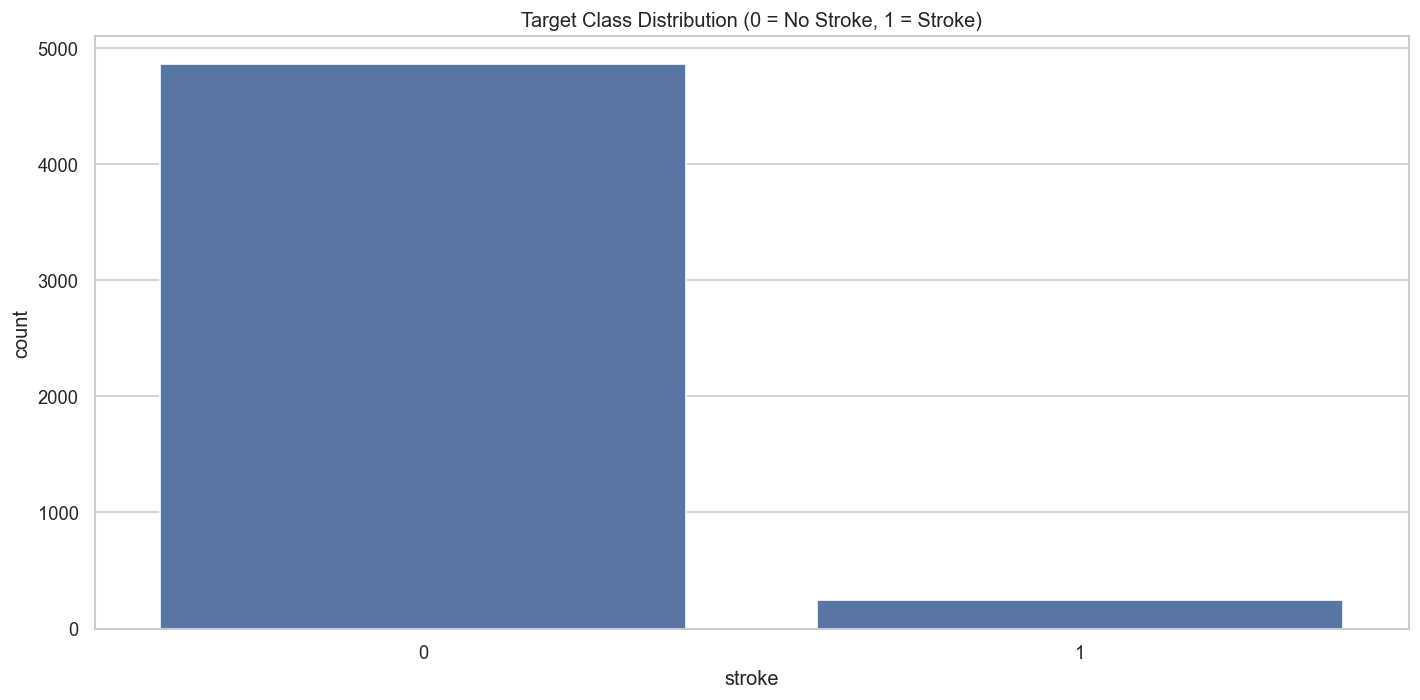

In [7]:
target_col = "stroke"

print("\nTarget value counts:")
print(df[target_col].value_counts())

print("\nTarget distribution (normalized):")
print(df[target_col].value_counts(normalize=True))

sns.countplot(x=target_col, data=df)
plt.title("Target Class Distribution (0 = No Stroke, 1 = Stroke)")
plt.show()


**Interpretation:**

- If the percentage of `stroke = 1` is **very small** (e.g. ~5%), the dataset is **imbalanced**.
- In real projects, this is common for medical events, fraud, rare failures, etc.
- We'll keep this in mind when evaluating models: accuracy alone can be misleading.


## 4. Exploratory Data Analysis (EDA)

We start with simple **summary statistics** to understand distributions, ranges, and potential outliers.


In [8]:
# Describe numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


### 4.1 Identify Numeric vs Categorical Columns

We separate columns into:

- **Numeric features** → use scaling (StandardScaler)
- **Categorical features** → use one-hot encoding (OneHotEncoder)


In [6]:
# We assume target column is 'stroke'
features = df.drop(columns=[target_col])

numeric_cols = features.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = features.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


### 4.2 Distributions of Key Numeric Features

We plot histograms to see shapes of distributions and potential outliers.

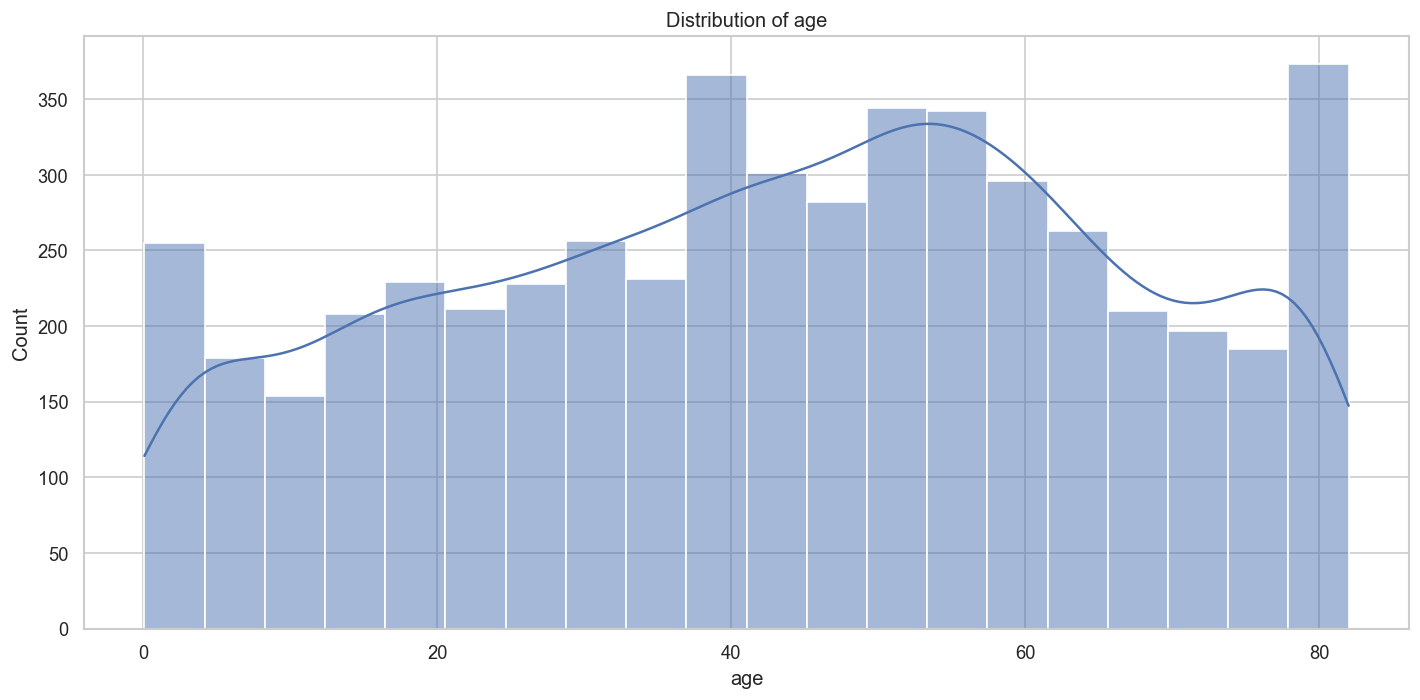

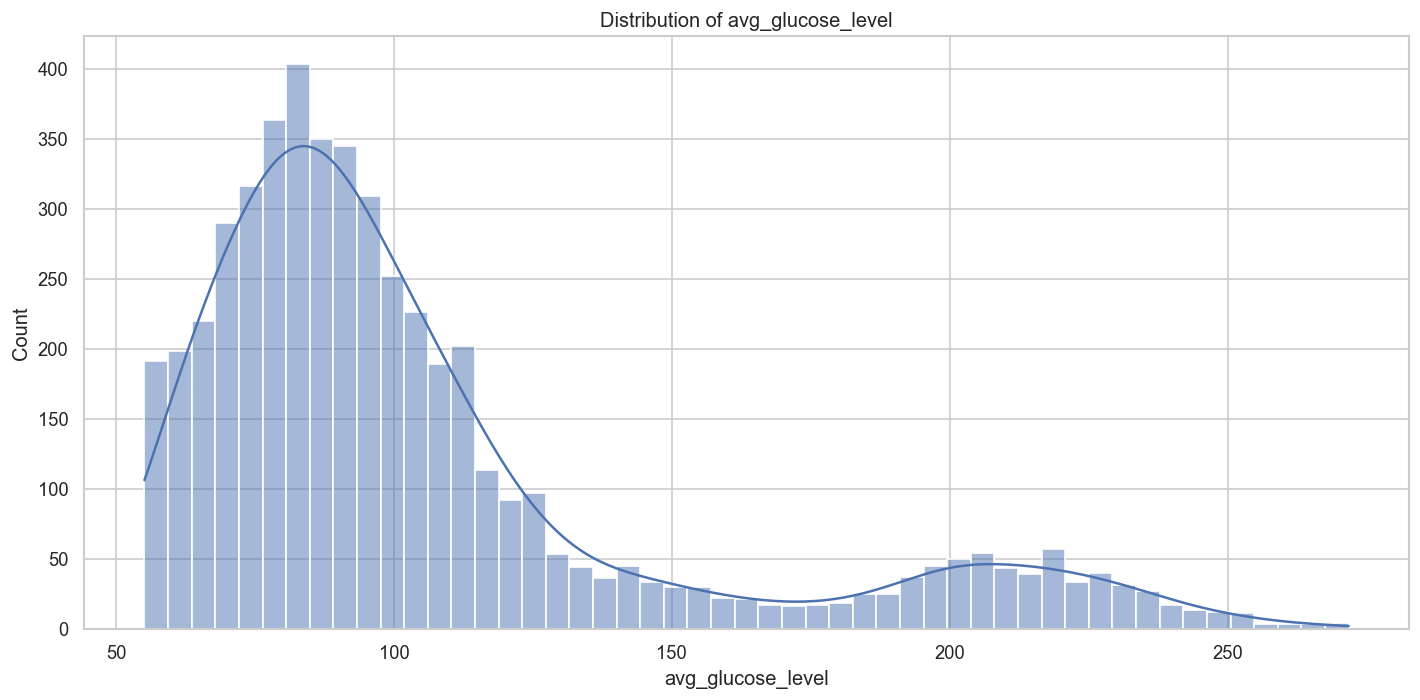

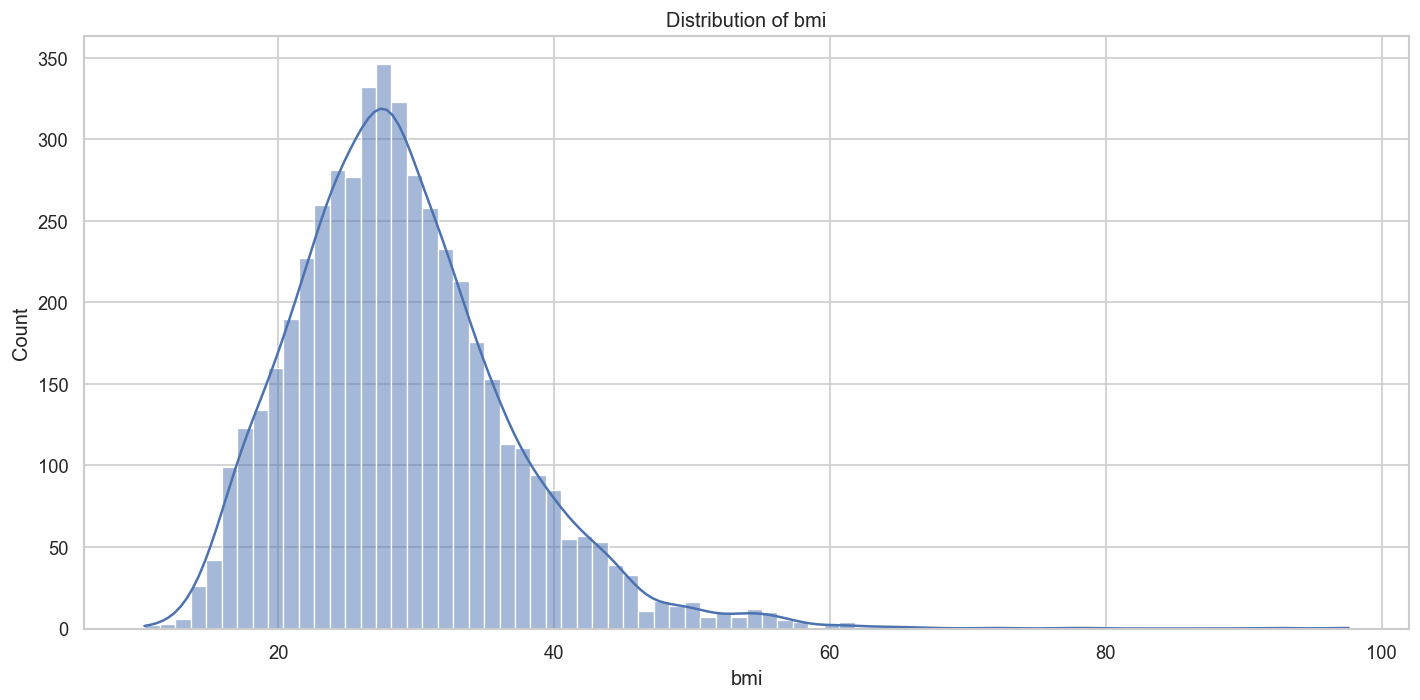

In [9]:
key_numeric = ["age", "avg_glucose_level", "bmi"]

for col in key_numeric:
    if col in df.columns:
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()


### 4.3 Categorical Features vs Target

We look at how categories are related to stroke occurrence (0/1).

In [8]:
df["stroke"].dtype

dtype('int64')


=== gender vs stroke ===


stroke,0,1
gender,,
Female,0.952906,0.047094
Male,0.948936,0.051064
Other,1.000000,0.000000


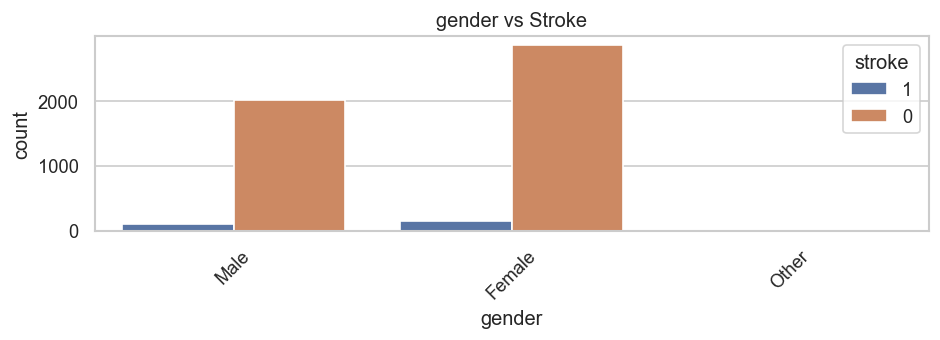


=== ever_married vs stroke ===


stroke,0,1
ever_married,,
No,0.983495,0.016505
Yes,0.934387,0.065613


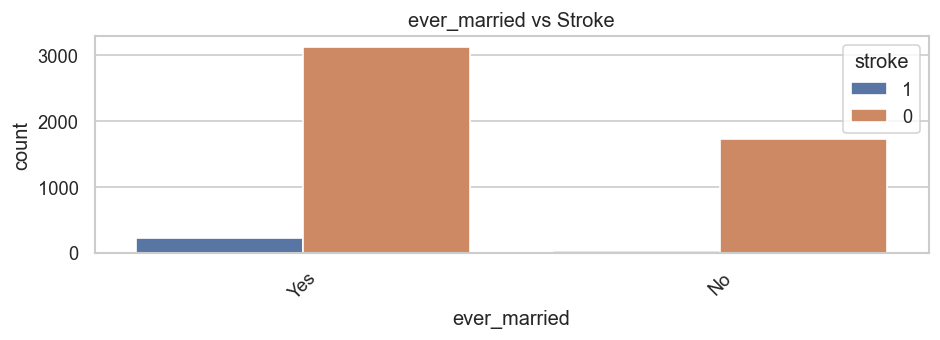


=== work_type vs stroke ===


stroke,0,1
work_type,,
Govt_job,0.949772,0.050228
Never_worked,1.000000,0.000000
Private,0.949060,0.050940
Self-employed,0.920635,0.079365
children,0.997089,0.002911


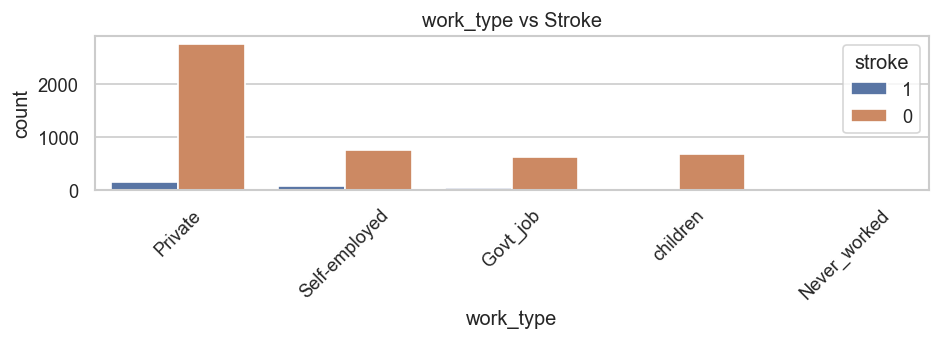


=== Residence_type vs stroke ===


stroke,0,1
Residence_type,,
Rural,0.954654,0.045346
Urban,0.947997,0.052003


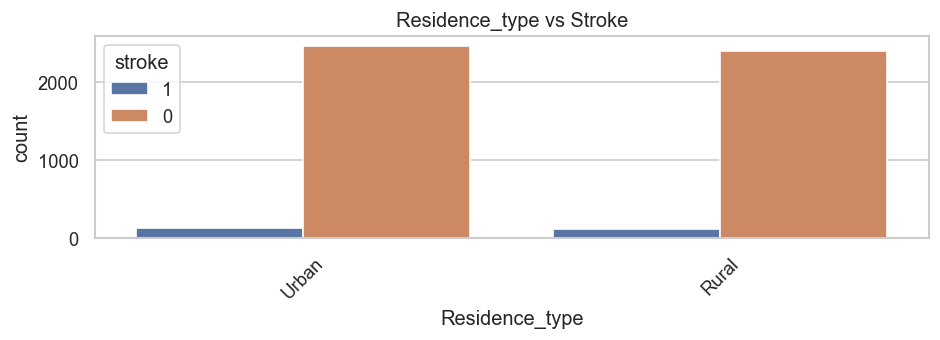


=== smoking_status vs stroke ===


stroke,0,1
smoking_status,,
Unknown,0.969560,0.030440
formerly smoked,0.920904,0.079096
never smoked,0.952431,0.047569
smokes,0.946768,0.053232


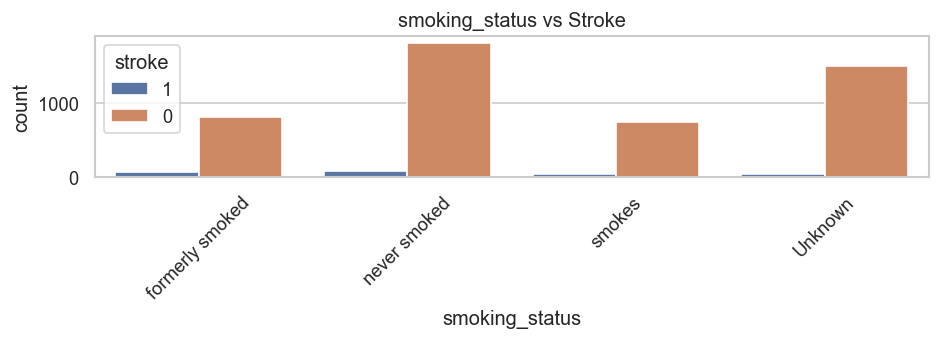

In [10]:
cat_to_check = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
df["stroke"] = df["stroke"].astype("str")
for col in cat_to_check:
    if col in df.columns:
        print(f"\n=== {col} vs stroke ===")
        display(pd.crosstab(df[col], df[target_col], normalize="index"))
        plt.figure(figsize = (8,3))
        sns.countplot(x=col, hue="stroke", data=df)
        plt.title(f"{col} vs Stroke")
        plt.xticks(rotation=45)
        plt.show()


### 4.4 Correlation Heatmap (Numeric Features)

Correlation helps us see linear relationships between numeric features and the target (if numeric).

In [11]:
# Compute correlation only on numeric columns (including target)
numeric_df = df[numeric_cols + [target_col]]
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features + Target)")
plt.show()


NameError: name 'numeric_cols' is not defined

## 5. Data Cleaning

Typical tasks:

1. **Drop irrelevant columns** (e.g., `id` if present)
2. **Handle missing values** (e.g., `bmi` often has missing values)
3. **Fix obvious invalid values** if needed
4. **Check duplicates**

We will do a **simple but realistic** cleaning here.


In [12]:
df_clean = df.copy()

# 1. Drop an ID column if it exists (it doesn't help prediction)
if "id" in df_clean.columns:
    df_clean = df_clean.drop(columns=["id"])
    print("Dropped 'id' column.")

# 2. Handle 'bmi' missing values (if present)
if "bmi" in df_clean.columns:
    print("\nMissing values in bmi BEFORE:", df_clean["bmi"].isnull().sum())
    # Convert strings like 'N/A' if present
    df_clean["bmi"] = pd.to_numeric(df_clean["bmi"], errors="coerce")
    # Impute with median
    median_bmi = df_clean["bmi"].median()
    df_clean["bmi"].fillna(median_bmi, inplace=True)
    print("Missing values in bmi AFTER:", df_clean["bmi"].isnull().sum())

# 3. Check duplicates
print("\nNumber of duplicate rows BEFORE:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Number of duplicate rows AFTER:", df_clean.duplicated().sum())

print("\nCleaned dataset shape:", df_clean.shape)


Dropped 'id' column.

Missing values in bmi BEFORE: 201
Missing values in bmi AFTER: 0

Number of duplicate rows BEFORE: 0
Number of duplicate rows AFTER: 0

Cleaned dataset shape: (5110, 11)


> 💡 **Teaching point:**  
> In real projects, data cleaning can take **50–80%** of the time.  
> Here we show a **medium-level** but still manageable pipeline for beginners.


## 6. Train–Test Split

We separate:

- **Features (X)** → all columns except `stroke`
- **Target (y)** → `stroke` column
- Split into **training** and **test** sets (e.g., 80% / 20%), with **stratification** to keep class balance similar in both.


In [13]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].astype("int")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class distribution
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (4088, 10)
Test set shape: (1022, 10)


## 7. Preprocessing Pipeline (Encoding + Scaling)

We build a **ColumnTransformer** that:

- Applies **StandardScaler** to numeric columns
- Applies **OneHotEncoder** to categorical columns

Then we plug this into a **Pipeline** together with different ML models.

This is a modern, production-like approach and matches many JD expectations.


In [14]:
# Recalculate numeric & categorical columns on cleaned data
features_clean = X_train.copy()
numeric_cols_clean = features_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_clean = features_clean.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns (clean):", numeric_cols_clean)
print("Categorical columns (clean):", categorical_cols_clean)

# Preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols_clean),
        ("cat", categorical_transformer, categorical_cols_clean),
    ]
)


Numeric columns (clean): ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical columns (clean): ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


## 8. Define Multiple Classification Models

We will compare several commonly asked/used algorithms:

1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**
4. **Random Forest**
5. **Support Vector Machine (SVM)**
6. **Naive Bayes**

For imbalanced data, we sometimes use `class_weight='balanced'` where available.


In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "Naive Bayes": GaussianNB()
}


## 9. Train & Evaluate All Models

For **each model**, we:

1. Build a Pipeline: `preprocessor` → `model`
2. Fit on training data
3. Predict on test data
4. Calculate **Accuracy, Precision, Recall**
5. Save results in a table for comparison


In [16]:
results = []
fitted_pipelines = {}

for name, clf in models.items():
    print(f"\n===== Training: {name} =====")
    
    # Create pipeline: preprocessing + classifier
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", clf)
    ])
    
    # Fit
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    
    # Predict
    y_pred = pipe.predict(X_test)
    
    # Metrics (use stroke=1 as positive class)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df



===== Training: Logistic Regression =====

===== Training: KNN =====

===== Training: Decision Tree =====

===== Training: Random Forest =====

===== Training: SVM (RBF) =====

===== Training: Naive Bayes =====


,Model,Accuracy,Precision,Recall
0,Naive Bayes,0.298434,0.064052,0.98
1,Logistic Regression,0.745597,0.137931,0.80
2,SVM (RBF),0.761252,0.132576,0.70
3,Decision Tree,0.928571,0.151515,0.10
4,KNN,0.948141,0.000000,0.00
5,Random Forest,0.950098,0.000000,0.00


> 🔍 **Why sort by Recall?**  
> In medical problems like stroke prediction, we often care more about **catching as many true stroke cases as possible** (high recall),  
> even if it means a few extra false alarms.


### 9.1 Visual Comparison of Model Performance

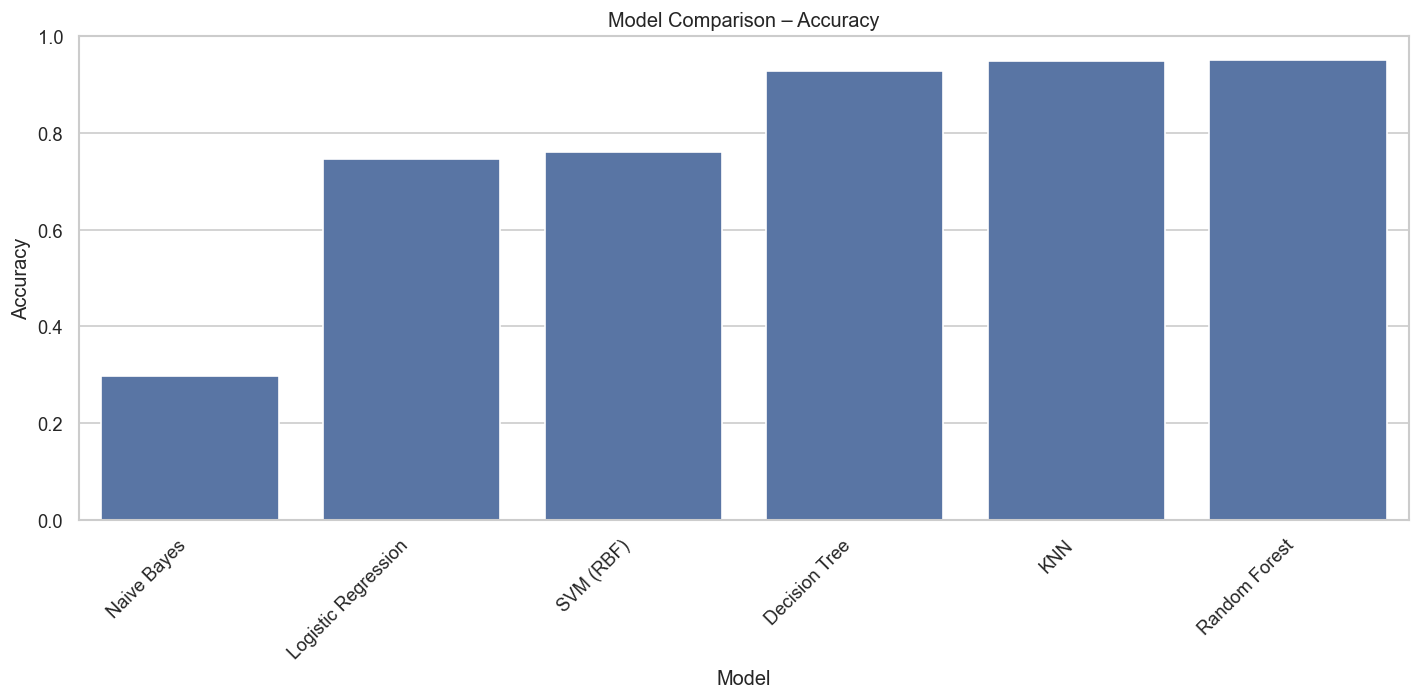

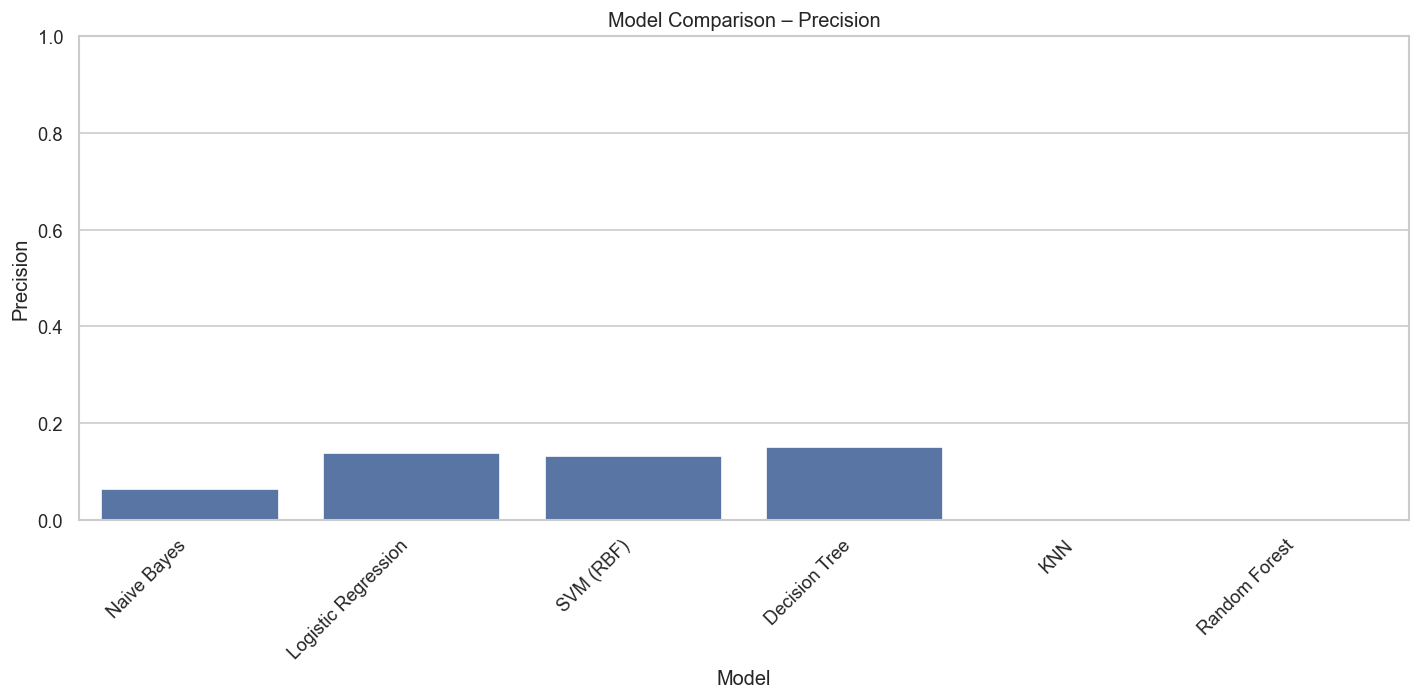

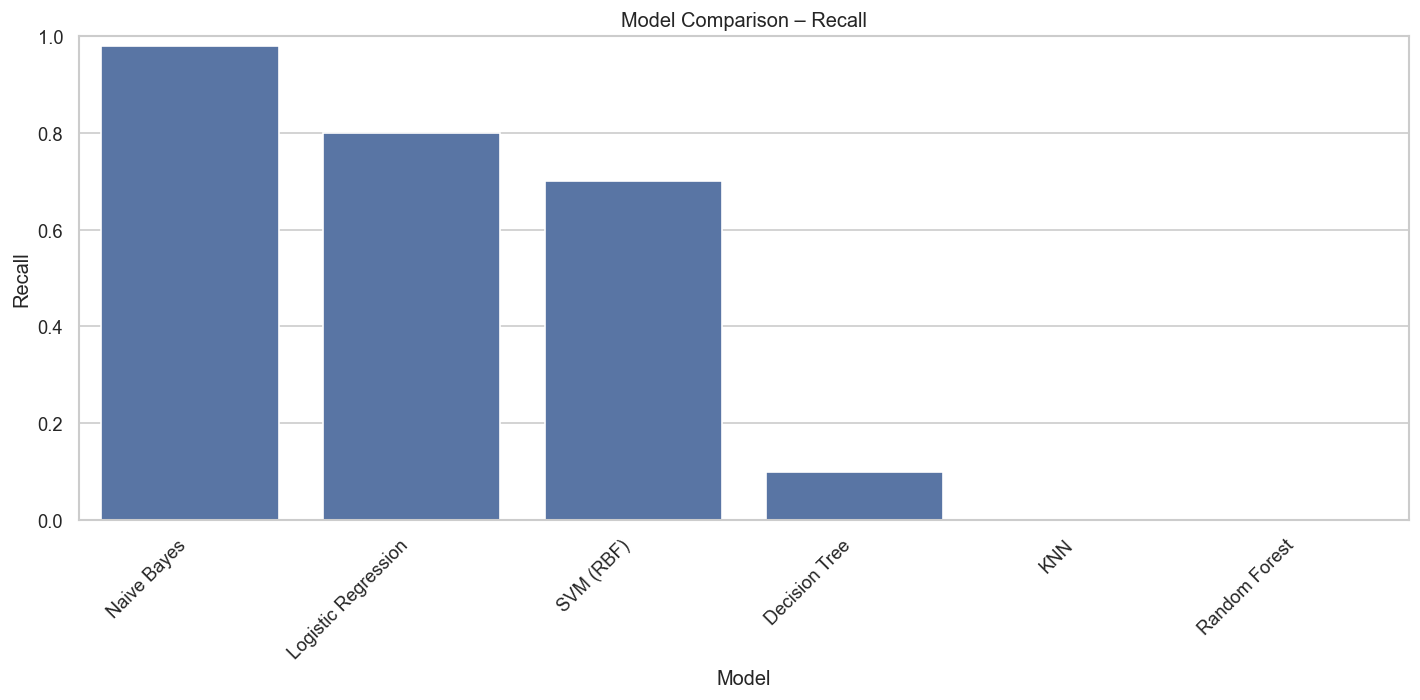

In [17]:
metrics_to_plot = ["Accuracy", "Precision", "Recall"]

for metric in metrics_to_plot:
    sns.barplot(x="Model", y=metric, data=results_df)
    plt.title(f"Model Comparison – {metric}")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.show()


## 10. Deep Dive into the Best Model (by Recall)

Let's take the model with the **highest Recall** and:

- Show its **classification report**
- Plot a **confusion matrix**


In [18]:
# Pick best model by Recall
best_model_name = results_df.iloc[0]["Model"]
print("Best model by Recall:", best_model_name)

best_pipeline = fitted_pipelines[best_model_name]

# Predictions
y_pred_best = best_pipeline.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["No Stroke", "Stroke"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
cm


Best model by Recall: Naive Bayes

Classification Report:
              precision    recall  f1-score   support

   No Stroke       1.00      0.26      0.42       972
      Stroke       0.06      0.98      0.12        50

    accuracy                           0.30      1022
   macro avg       0.53      0.62      0.27      1022
weighted avg       0.95      0.30      0.40      1022



array([[256, 716],
       [  1,  49]], dtype=int64)

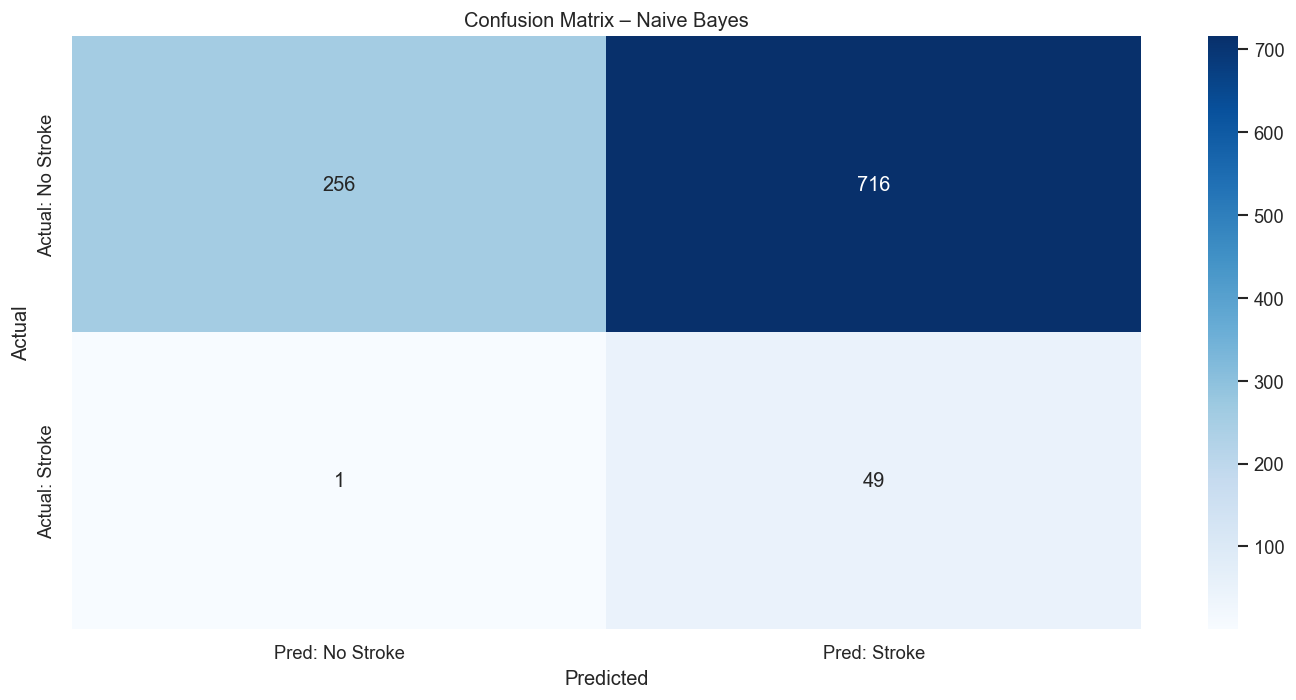

In [18]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No Stroke", "Pred: Stroke"],
            yticklabels=["Actual: No Stroke", "Actual: Stroke"])
plt.title(f"Confusion Matrix – {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


## 11. Summary – Mapping Back to Fresher JD

What skills did we demonstrate?

1. **Data Extraction / Loading**
   - Loaded a real-world healthcare CSV with `pandas.read_csv()`

2. **Data Cleaning**
   - Dropped an ID column (`id`)
   - Handled missing values in `bmi` with median imputation
   - Removed duplicate rows

3. **Data Preprocessing**
   - Identified numeric vs categorical features
   - Built a **ColumnTransformer** with:
     - `StandardScaler` for numeric
     - `OneHotEncoder` for categorical
   - Combined everything in **Pipelines**

4. **EDA with Stats & Visualization**
   - `df.info()`, `df.describe()`
   - Distributions (histograms)
   - Categorical vs target (`crosstab`, countplots)
   - Correlation heatmap

5. **Multiple ML Algorithms (Classification)**
   - Logistic Regression, KNN, Decision Tree, Random Forest, SVM, Naive Bayes

6. **Evaluation Metrics**
   - Accuracy, Precision, Recall
   - Confusion matrix
   - Classification report

7. **Communication & Documentation**
   - Markdown explanations at each step
   - Clear code comments suitable for fresher training

---

### 11.1 Suggestions for Classroom Exercises



- Try different **train/test split** ratios (e.g., 70/30).
- Change model hyperparameters (e.g., `max_depth` for Decision Tree, `n_neighbors` for KNN).
- Add **F1-score** and **ROC-AUC** to the metrics.
- Experiment with **class imbalance techniques** (e.g., SMOTE, class_weight variations).
- Try another modern dataset (e.g., credit card fraud, churn prediction, loan default).

This single notebook can be used across multiple sessions to cover:  
**Python basics → EDA → preprocessing → ML → metrics → business interpretation.**


In [19]:
import joblib
joblib.dump(best_pipeline, "stroke_prediction_model.pkl")

['stroke_prediction_model.pkl']

In [20]:
print(joblib.__version__)

1.4.2


In [1]:
pip install scikit-learn==1.5.1

In [1]:
import sklearn
print(sklearn.__version__)

1.5.1


In [19]:
import joblib
joblib.dump(best_pipeline, "stroke_prediction_model(1).pkl")

['stroke_prediction_model(1).pkl']